In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# indlæs GDP-data
GDP = pd.read_csv("GDP.csv", skiprows=4)

# indlæs Human-Productivity.xlsx
HP = pd.read_excel("Human-Productivity.xlsx", sheet_name="Data")

# indlæs lifeexpectancy.csv
LE = pd.read_csv("lifeexpectancy.csv")

# indlæs medianage.csv
MA = pd.read_csv("medianage.csv")

In [3]:
# ----------- GDP panel data ----------
GDP_long = GDP.melt(
    id_vars=["Country Name","Country Code"],
    var_name="year",
    value_name="gdp_pc"
)

GDP_long = GDP_long.rename(columns={
    "Country Name":"country",
    "Country Code":"code"
})

# ----------- Human capital and productivity panel data ----------
HP_panel = HP[["country","year","hc","ctfp"]]

HP_panel = HP_panel.rename(columns={
    "hc":"human_capital",
    "ctfp":"productivity"
})

# ----------- Life expectancy panel data ----------
LE_long = LE.rename(columns={
    "Entity":"country",
    "Year":"year",
    "Life expectancy":"life_exp"
})

LE_long = LE_long[["country","year","life_exp"]]

# ----------- Medianage panel data ---------
MA_long = MA.rename(columns={
    "Entity":"country",
    "Year":"year",
    "Median age, total":"median_age"
})

MA_long = MA_long[["country","year","median_age"]]

Merge datasættene sammen

In [4]:
# behold kun rigtige år
GDP_long = GDP_long[GDP_long["year"].astype(str).str.isnumeric()].copy()

# gør year til int
GDP_long["year"] = GDP_long["year"].astype(int)

# samme datatype i alle datasæt
MA_long["year"] = MA_long["year"].astype(int)
LE_long["year"] = LE_long["year"].astype(int)
HP_panel["year"] = HP_panel["year"].astype(int)

# merge alle datasæt til én paneldataframe
panel = GDP_long.merge(MA_long, on=["country","year"], how="left")
panel = panel.merge(LE_long, on=["country","year"], how="left")
panel = panel.merge(HP_panel, on=["country","year"], how="left")

In [5]:
# konverter gdp_pc til numerisk datatype
panel["gdp_pc"] = pd.to_numeric(panel["gdp_pc"], errors="coerce")

# log-transformer gdp_pc
panel["ln_gdp_pc"] = np.log(panel["gdp_pc"])

In [6]:
# behold kun år 2000-2026
panel = panel[(panel["year"] >= 2000) & (panel["year"] <= 2026)]

panel = panel.dropna(subset=[
    "ln_gdp_pc",
    "median_age",
    "life_exp",
    "human_capital",
    "productivity"
])

In [7]:
# print antal lande
print(panel["country"].nunique())

# print antal år 
print(panel["year"].nunique())

# print antal observationer
print(panel.shape)

104
24
(2496, 9)


In [8]:
# tjek for missing values
panel.isna().sum()

country          0
code             0
year             0
gdp_pc           0
median_age       0
life_exp         0
human_capital    0
productivity     0
ln_gdp_pc        0
dtype: int64

Det er et balanceret panel.

### korrelationer

In [9]:
# korrelationer mellem variablerne
panel[[
    "ln_gdp_pc",
    "median_age",
    "life_exp",
    "human_capital",
    "productivity"
]].corr()

,ln_gdp_pc,median_age,life_exp,human_capital,productivity
ln_gdp_pc,1.000000,0.796196,0.834664,0.787121,0.755651
median_age,0.796196,1.000000,0.802293,0.830842,0.607208
life_exp,0.834664,0.802293,1.000000,0.764436,0.618949
human_capital,0.787121,0.830842,0.764436,1.000000,0.561247
productivity,0.755651,0.607208,0.618949,0.561247,1.000000


### Visuelt korrelationer

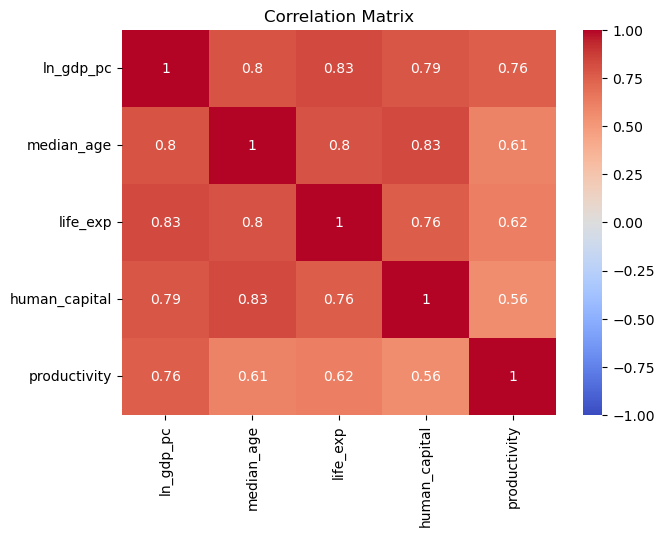

In [10]:
# vælg de variabler vi vil analysere
vars_corr = panel[[
    "ln_gdp_pc",
    "median_age",
    "life_exp",
    "human_capital",
    "productivity"
]]

# beregn korrelation
corr_matrix = vars_corr.corr()

# plot heatmap
plt.figure(figsize=(7,5))
sns.heatmap(
    corr_matrix,
    annot=True,        # skriv tallene i felterne
    cmap="coolwarm",   # farveskala
    vmin=-1, vmax=1    # korrelationsinterval
)

plt.title("Correlation Matrix")
plt.show()

Hvordan du læser figuren

Mørk rød → stærk positiv sammenhæng

Mørk blå → stærk negativ sammenhæng

Lys farve → svag sammenhæng

Tallene i felterne er samme korrelationer som i tabellen

Rige lande har typisk:

ældre befolkning

højere levealder

mere human capital

højere produktivitet

Det passer godt med udviklingsøkonomi.

In [11]:
#print panel første 5 rækker
panel.head()

,country,code,year,gdp_pc,median_age,life_exp,human_capital,productivity,ln_gdp_pc
10644,Angola,AGO,2000,3689.537808,16.040,46.5005,1.296941,0.139858,8.213256
10645,Albania,ALB,2000,3977.771869,26.217,74.8262,2.801147,0.337635,8.288477
10649,Argentina,ARG,2000,11499.982800,26.837,73.9100,2.657196,0.720260,9.350101
10650,Armenia,ARM,2000,2530.743947,28.559,70.8123,3.098649,0.264571,7.836269
10653,Australia,AUS,2000,26584.819197,34.369,79.6207,3.538635,0.864832,10.188096


In [12]:
panel["gdp_pc"].describe()

count      2496.000000
mean      22974.046047
std       23513.007252
min         471.967330
25%        6422.035309
50%       14426.874964
75%       33444.535645
max      180939.439450
Name: gdp_pc, dtype: float64

In [33]:
import statsmodels.formula.api as smf

pooled = smf.ols(
    "ln_gdp_pc ~ median_age + human_capital + productivity",
    data=panel
).fit()

print(pooled.summary())

                            OLS Regression Results                            
Dep. Variable:              ln_gdp_pc   R-squared:                       0.785
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     3031.
Date:                Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:46:14   Log-Likelihood:                -2036.4
No. Observations:                2496   AIC:                             4081.
Df Residuals:                    2492   BIC:                             4104.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         5.6236      0.045    123.795

In [13]:
import statsmodels.formula.api as smf

pooled = smf.ols(
    "ln_gdp_pc ~ median_age + human_capital + productivity + life_exp",
    data=panel
).fit()

print(pooled.summary())

                            OLS Regression Results                            
Dep. Variable:              ln_gdp_pc   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.825
Method:                 Least Squares   F-statistic:                     2935.
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:23:06   Log-Likelihood:                -1779.0
No. Observations:                2496   AIC:                             3568.
Df Residuals:                    2491   BIC:                             3597.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         3.6860      0.091     40.558

Median age, human capital, productivity og life expectancy er alle positivt og signifikant associeret med BNP pr. capita.

In [14]:
import statsmodels.formula.api as smf

fe_model = smf.ols(
    "ln_gdp_pc ~ median_age + human_capital + productivity + life_exp + C(country)",
    data=panel
).fit()

print(fe_model.summary())

                            OLS Regression Results                            
Dep. Variable:              ln_gdp_pc   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     1068.
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:23:06   Log-Likelihood:                 899.63
No. Observations:                2496   AIC:                            -1583.
Df Residuals:                    2388   BIC:                            -954.4
Df Model:                         107                                         
Covariance Type:            nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

In [15]:
panel = panel.sort_values(["country", "year"])

In [16]:
panel["d_ln_gdp_pc"] = panel.groupby("country")["ln_gdp_pc"].diff()
panel["d_median_age"] = panel.groupby("country")["median_age"].diff()
panel["d_human_capital"] = panel.groupby("country")["human_capital"].diff()
panel["d_productivity"] = panel.groupby("country")["productivity"].diff()
panel["d_life_exp"] = panel.groupby("country")["life_exp"].diff()

In [17]:
fd_data = panel.dropna()

In [18]:
import statsmodels.formula.api as smf

fd_model = smf.ols(
    "d_ln_gdp_pc ~ d_median_age + d_human_capital + d_productivity + d_life_exp",
    data=fd_data
).fit(cov_type="HC1")

print(fd_model.summary())

                            OLS Regression Results                            
Dep. Variable:            d_ln_gdp_pc   R-squared:                       0.189
Model:                            OLS   Adj. R-squared:                  0.187
Method:                 Least Squares   F-statistic:                     26.61
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           1.27e-21
Time:                        13:23:06   Log-Likelihood:                 3425.5
No. Observations:                2392   AIC:                            -6841.
Df Residuals:                    2387   BIC:                            -6812.
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0410      0.003     

In [19]:
between = panel.groupby("country")[[
    "ln_gdp_pc",
    "median_age",
    "human_capital",
    "productivity",
    "life_exp"
]].mean().reset_index()

In [20]:
import statsmodels.formula.api as smf

be_model = smf.ols(
    "ln_gdp_pc ~ median_age + human_capital + productivity + life_exp",
    data=between
).fit(cov_type="HC1")

print(be_model.summary())

                            OLS Regression Results                            
Dep. Variable:              ln_gdp_pc   R-squared:                       0.862
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     138.7
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           1.12e-39
Time:                        13:23:06   Log-Likelihood:                -57.740
No. Observations:                 104   AIC:                             125.5
Df Residuals:                      99   BIC:                             138.7
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         3.7398      0.486      7.689

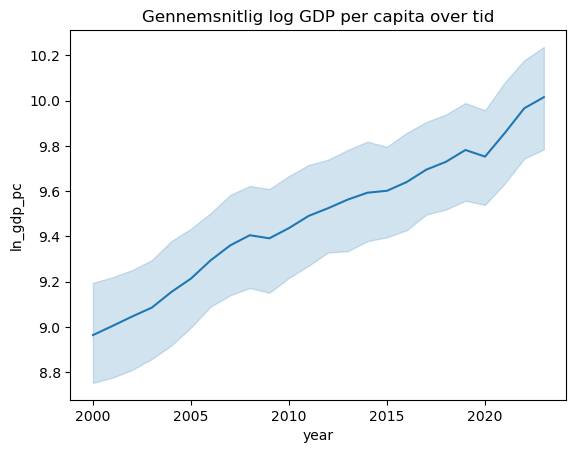

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# hvordan BNP udvikler sig:
sns.lineplot(data=panel, x="year", y="ln_gdp_pc", estimator="mean")
plt.title("Gennemsnitlig log GDP per capita over tid")
plt.show()

Kort konklusion:

BNP per capita stiger over tid → global økonomisk vækst

Stigningen er ret stabil → ingen store fald (fx kriser kun svagt synlige)

Spredningen (det blå område) viser forskelle mellem lande, men trenden er stadig opad

Konklusion: Verden er generelt blevet rigere fra 2000–2023, på tværs af lande.

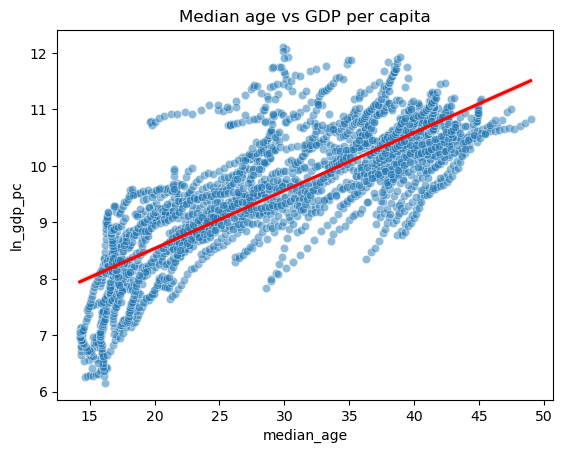

In [ ]:
# Sammenhæng mellem GDP og median age
sns.scatterplot(data=panel, x="median_age", y="ln_gdp_pc", alpha=0.5)
sns.regplot(data=panel, x="median_age", y="ln_gdp_pc", scatter=False, color="red")

plt.title("Median age vs GDP per capita")
plt.show()

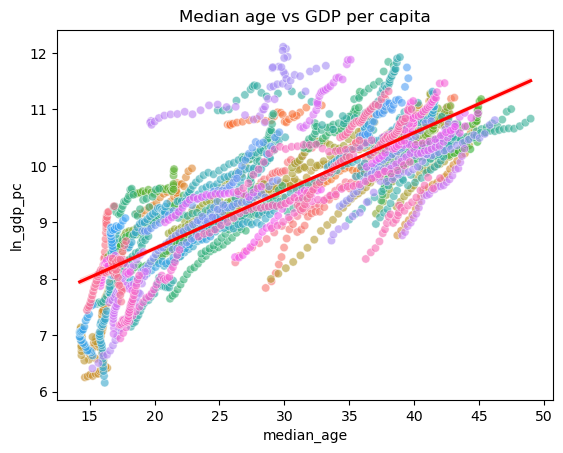

In [28]:
sns.scatterplot(
    data=panel,
    x="median_age",
    y="ln_gdp_pc",
    hue="country",   # 👈 farve pr. land
    alpha=0.6,
    legend=False     # fjerner kæmpe legend (anbefales!)
)

sns.regplot(
    data=panel,
    x="median_age",
    y="ln_gdp_pc",
    scatter=False,
    color="red"
)

plt.title("Median age vs GDP per capita")
plt.show()

Kort konklusion 

Klar positiv sammenhæng: højere median age → højere BNP per capita

Lande med ældre befolkning er typisk rigere

Der er noget spredning → andre faktorer spiller også ind

Konklusion: Demografisk udvikling (aldring) hænger stærkt sammen med økonomisk udvikling.

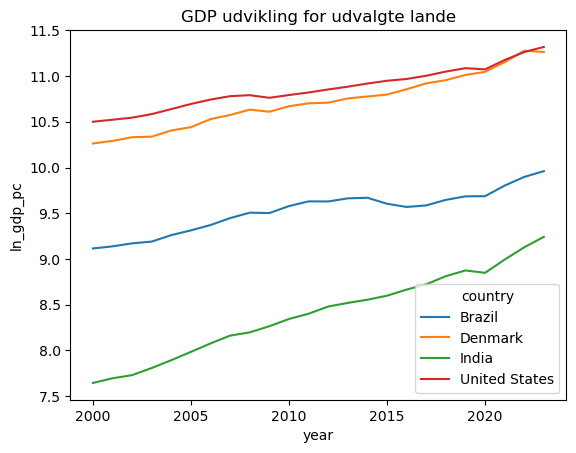

In [ ]:
# BNP udvikling for udvalgte lande
countries = ["Denmark", "United States", "India", "Brazil"]

subset = panel[panel["country"].isin(countries)]

sns.lineplot(data=subset, x="year", y="ln_gdp_pc", hue="country")
plt.title("GDP udvikling for udvalgte lande")
plt.show()

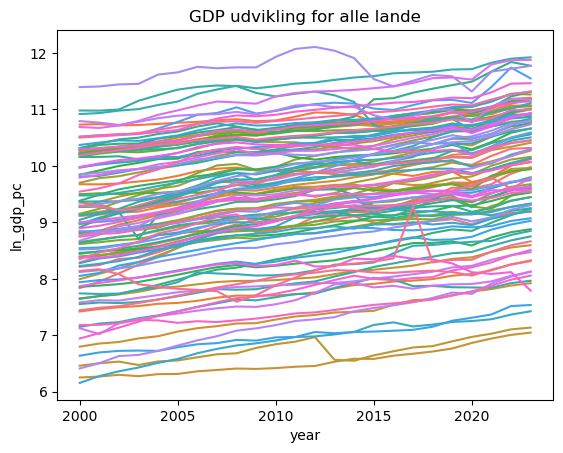

In [27]:
# BNP udvikling for alle lande
sns.lineplot(data=panel, x="year", y="ln_gdp_pc", hue="country", legend=False)
plt.title("GDP udvikling for alle lande")
plt.show()

Kort konklusion 

Alle lande vokser over tid → BNP stiger i alle tilfælde

USA og Danmark ligger højest → rige lande forbliver rige

Indien vokser hurtigst relativt → catching-up effekt

Brazil vokser, men langsommere

Konklusion: Der er global vækst, men stadig store forskelle mellem lande – dog tegn på konvergens for fattigere lande.

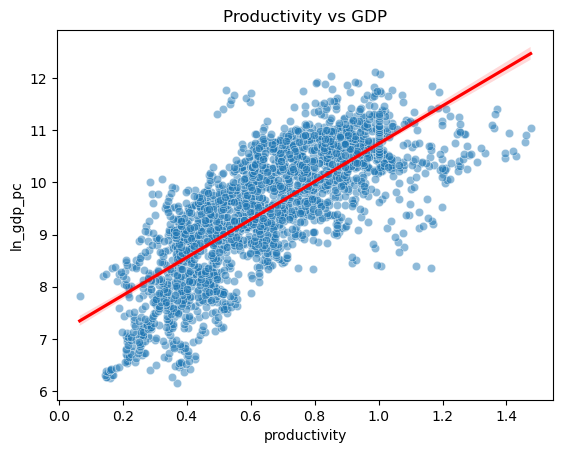

In [ ]:
# Sammenhæng mellem GDP og produktivitet
sns.scatterplot(data=panel, x="productivity", y="ln_gdp_pc", alpha=0.5)
sns.regplot(data=panel, x="productivity", y="ln_gdp_pc", scatter=False, color="red")

plt.title("Productivity vs GDP")
plt.show()

Kort konklusion 

Meget stærk positiv sammenhæng: høj produktivitet → højere BNP

Punkterne ligger tæt → sammenhængen er ret stærk og stabil

Understøtter jeres regression (productivity er vigtigst)

Konklusion: Produktivitet er en central driver for økonomisk velstand.

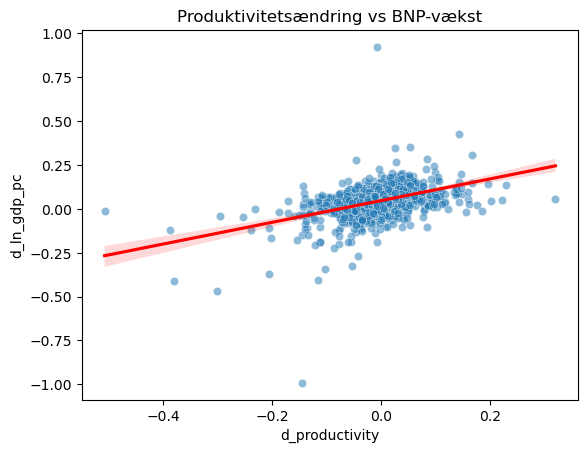

In [26]:
sns.scatterplot(data=fd_data, x="d_productivity", y="d_ln_gdp_pc", alpha=0.5)
sns.regplot(data=fd_data, x="d_productivity", y="d_ln_gdp_pc", scatter=False, color="red")

plt.title("Produktivitetsændring vs BNP-vækst")
plt.show()

Kort konklusion 

Positiv sammenhæng: stigning i produktivitet → højere BNP-vækst

Sammenhængen er svagere og mere spredt end før

Mange outliers → vækst er mere volatil

Konklusion: Produktivitet driver også økonomisk vækst, men effekten er mere usikker på kort sigt.

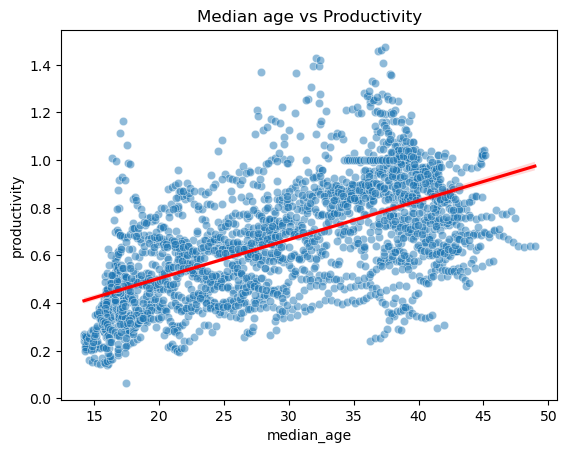

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=panel,
    x="median_age",
    y="productivity",
    alpha=0.5
)

sns.regplot(
    data=panel,
    x="median_age",
    y="productivity",
    scatter=False,
    color="red"
)

plt.title("Median age vs Productivity")
plt.show()

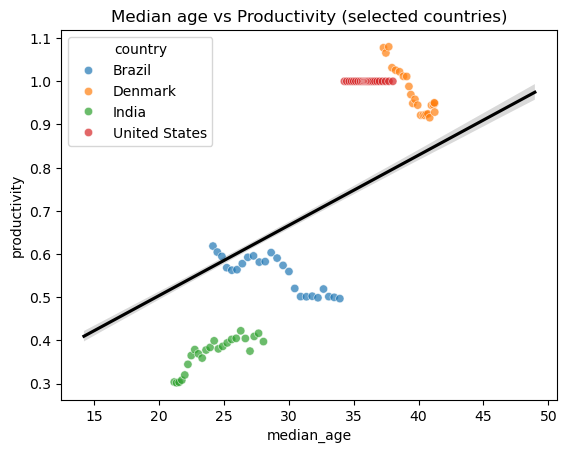

In [31]:
countries = ["Denmark", "United States", "India", "Brazil"]
subset = panel[panel["country"].isin(countries)]

sns.scatterplot(
    data=subset,
    x="median_age",
    y="productivity",
    hue="country",
    alpha=0.7
)

sns.regplot(
    data=panel,
    x="median_age",
    y="productivity",
    scatter=False,
    color="black"
)

plt.title("Median age vs Productivity (selected countries)")
plt.show()

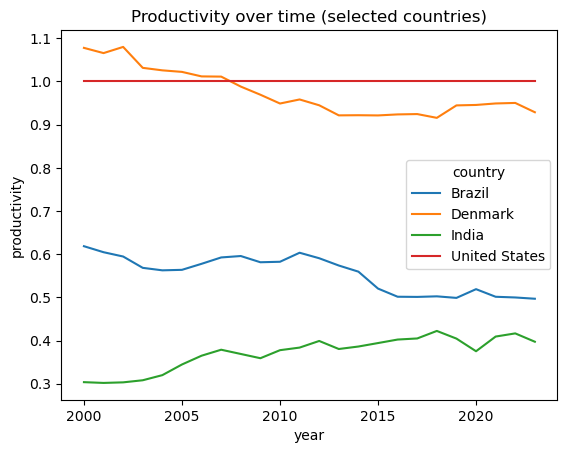

In [32]:
sns.lineplot(
    data=subset,
    x="year",
    y="productivity",
    hue="country"
)

plt.title("Productivity over time (selected countries)")
plt.show()

In [34]:
panel = panel.sort_values(["country", "year"])

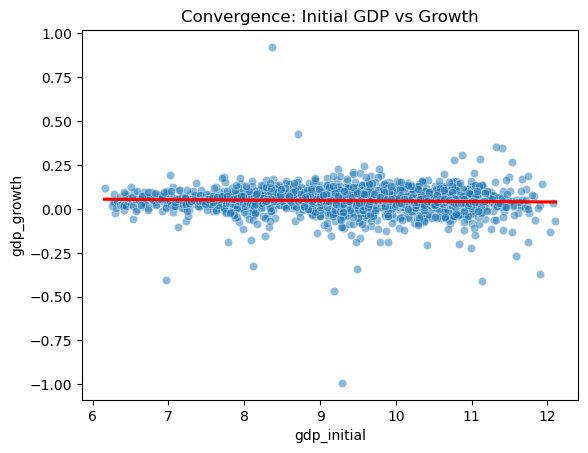

In [35]:
panel["gdp_growth"] = panel.groupby("country")["ln_gdp_pc"].diff()
panel["gdp_initial"] = panel.groupby("country")["ln_gdp_pc"].shift(1)

sns.scatterplot(
    data=panel,
    x="gdp_initial",
    y="gdp_growth",
    alpha=0.5
)

sns.regplot(
    data=panel,
    x="gdp_initial",
    y="gdp_growth",
    scatter=False,
    color="red"
)

plt.title("Convergence: Initial GDP vs Growth")
plt.show()

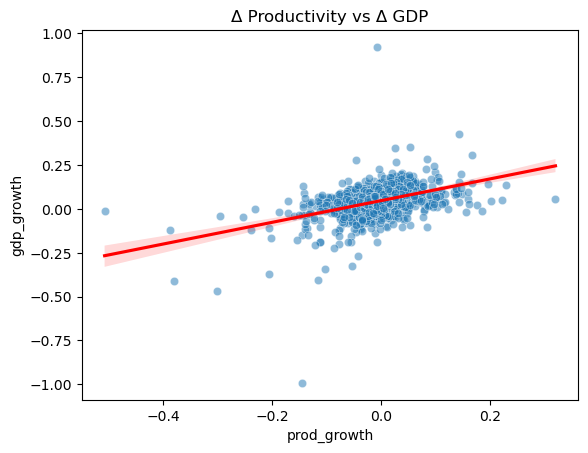

In [36]:
panel["prod_growth"] = panel.groupby("country")["productivity"].diff()

sns.scatterplot(
    data=panel,
    x="prod_growth",
    y="gdp_growth",
    alpha=0.5
)

sns.regplot(
    data=panel,
    x="prod_growth",
    y="gdp_growth",
    scatter=False,
    color="red"
)

plt.title("Δ Productivity vs Δ GDP")
plt.show()

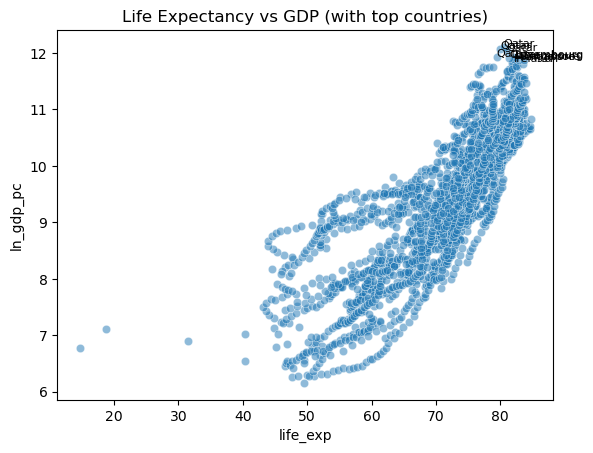

In [37]:
sns.scatterplot(
    data=panel,
    x="life_exp",
    y="ln_gdp_pc",
    alpha=0.5
)

# label de rigeste observationer
top = panel.nlargest(10, "ln_gdp_pc")

for i, row in top.iterrows():
    plt.text(row["life_exp"], row["ln_gdp_pc"], row["country"], fontsize=8)

plt.title("Life Expectancy vs GDP (with top countries)")
plt.show()

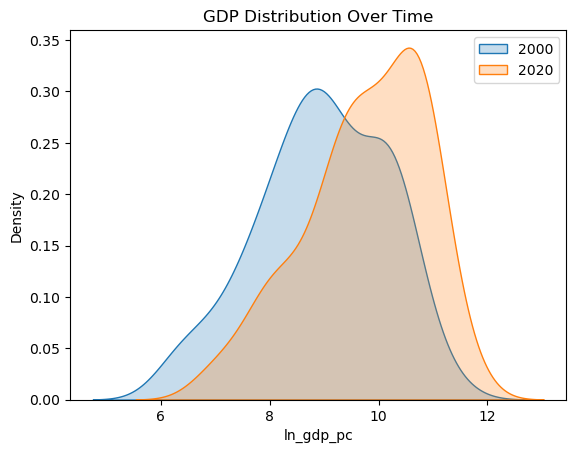

In [38]:
sns.kdeplot(
    data=panel[panel["year"] == 2000],
    x="ln_gdp_pc",
    label="2000",
    fill=True
)

sns.kdeplot(
    data=panel[panel["year"] == 2020],
    x="ln_gdp_pc",
    label="2020",
    fill=True
)

plt.legend()
plt.title("GDP Distribution Over Time")
plt.show()

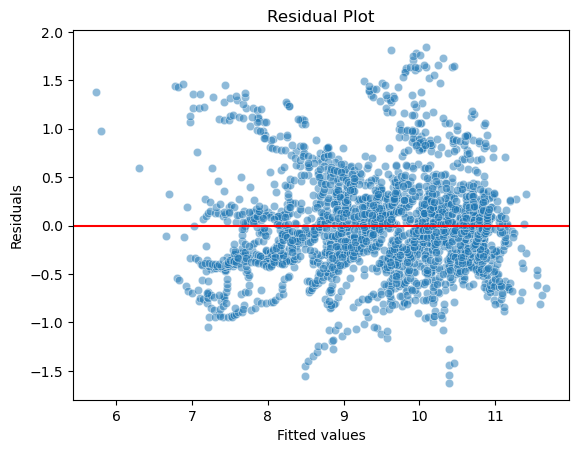

In [39]:
import statsmodels.api as sm

X = panel[["median_age", "human_capital", "productivity", "life_exp"]]
X = sm.add_constant(X)
y = panel["ln_gdp_pc"]

model = sm.OLS(y, X).fit()

sns.scatterplot(x=model.fittedvalues, y=model.resid, alpha=0.5)
plt.axhline(0, color="red")

plt.title("Residual Plot")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

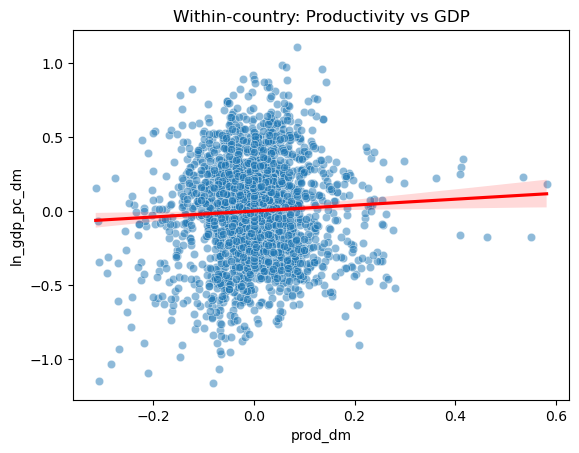

In [40]:
# fjern landes gennemsnit (within transformation)
panel["ln_gdp_pc_dm"] = panel["ln_gdp_pc"] - panel.groupby("country")["ln_gdp_pc"].transform("mean")
panel["prod_dm"] = panel["productivity"] - panel.groupby("country")["productivity"].transform("mean")

sns.scatterplot(
    data=panel,
    x="prod_dm",
    y="ln_gdp_pc_dm",
    alpha=0.5
)

sns.regplot(
    data=panel,
    x="prod_dm",
    y="ln_gdp_pc_dm",
    scatter=False,
    color="red"
)

plt.title("Within-country: Productivity vs GDP")
plt.show()